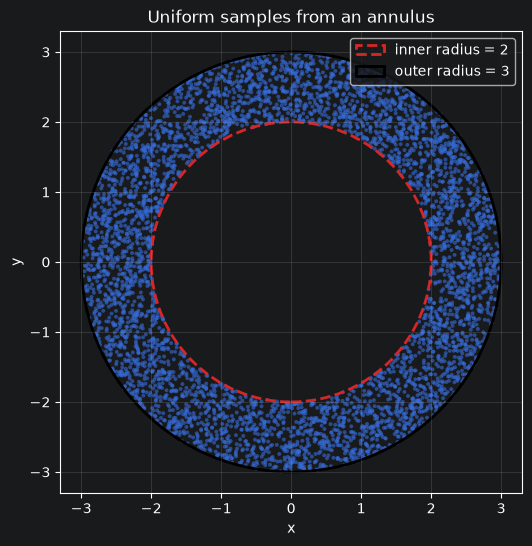

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Uniform sampling from the 2D annulus: 2 <= radius <= 3
rng = np.random.default_rng(42)
n_points = 5_000
inner_radius = 2.0
outer_radius = 3.0

theta = rng.uniform(0.0, 2.0 * np.pi, n_points)
r = np.sqrt(rng.uniform(inner_radius**2, outer_radius**2, n_points))

x = r * np.cos(theta)
y = r * np.sin(theta)
points = np.column_stack((x, y))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.6, edgecolors='none')

inner_boundary = plt.Circle((0, 0), inner_radius, fill=False, linestyle='--', color='tab:red', linewidth=2, label='inner radius = 2')
outer_boundary = plt.Circle((0, 0), outer_radius, fill=False, color='black', linewidth=2, label='outer radius = 3')
ax.add_patch(inner_boundary)
ax.add_patch(outer_boundary)

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Uniform samples from an annulus')
ax.legend(loc='upper right')
ax.grid(alpha=0.25)
plt.show()

Left Gaussian retained 2500 points; acceptance rate in generated batches: 68.35%
Right Gaussian retained 2500 points; acceptance rate in generated batches: 68.10%


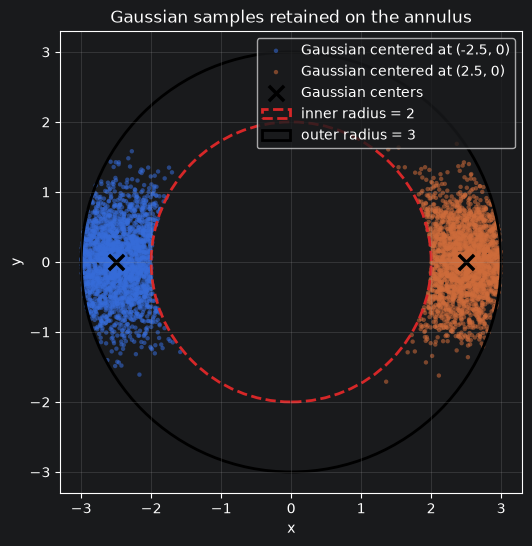

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Gaussian datasets conditioned to lie on the annulus: 2 <= radius <= 3
rng = np.random.default_rng(123)
inner_radius = 2.0
outer_radius = 3.0
variance = 0.25
n_points_per_gaussian = 2_500

mean_left = np.array([-2.5, 0.0])
mean_right = np.array([2.5, 0.0])

def in_annulus(samples, inner_radius=2.0, outer_radius=3.0):
    radii = np.linalg.norm(samples, axis=1)
    return (radii >= inner_radius) & (radii <= outer_radius)

def sample_gaussian_on_annulus(mean, variance, n_samples, rng, inner_radius=2.0, outer_radius=3.0, batch_size=10_000):
    std = np.sqrt(variance)
    accepted = []
    n_drawn = 0
    n_accepted = 0

    while n_accepted < n_samples:
        candidates = rng.normal(loc=mean, scale=std, size=(batch_size, 2))
        n_drawn += len(candidates)
        kept = candidates[in_annulus(candidates, inner_radius, outer_radius)]

        if len(kept) > 0:
            accepted.append(kept)
            n_accepted += len(kept)

    return np.vstack(accepted)[:n_samples], n_drawn, n_accepted

left_gaussian_points, left_drawn, left_accepted = sample_gaussian_on_annulus(
    mean_left, variance, n_points_per_gaussian, rng, inner_radius, outer_radius
)
right_gaussian_points, right_drawn, right_accepted = sample_gaussian_on_annulus(
    mean_right, variance, n_points_per_gaussian, rng, inner_radius, outer_radius
)

gaussian_ring_points = np.vstack((left_gaussian_points, right_gaussian_points))
gaussian_ring_labels = np.concatenate((
    np.zeros(n_points_per_gaussian, dtype=int),
    np.ones(n_points_per_gaussian, dtype=int),
))

print(f'Left Gaussian retained {n_points_per_gaussian} points; acceptance rate in generated batches: {left_accepted / left_drawn:.2%}')
print(f'Right Gaussian retained {n_points_per_gaussian} points; acceptance rate in generated batches: {right_accepted / right_drawn:.2%}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(left_gaussian_points[:, 0], left_gaussian_points[:, 1], s=10, alpha=0.55, edgecolors='none', label='Gaussian centered at (-2.5, 0)')
ax.scatter(right_gaussian_points[:, 0], right_gaussian_points[:, 1], s=10, alpha=0.55, edgecolors='none', label='Gaussian centered at (2.5, 0)')
ax.scatter([mean_left[0], mean_right[0]], [mean_left[1], mean_right[1]], marker='x', s=120, linewidths=2.5, color='black', label='Gaussian centers')

inner_boundary = plt.Circle((0, 0), inner_radius, fill=False, linestyle='--', color='tab:red', linewidth=2, label='inner radius = 2')
outer_boundary = plt.Circle((0, 0), outer_radius, fill=False, color='black', linewidth=2, label='outer radius = 3')
ax.add_patch(inner_boundary)
ax.add_patch(outer_boundary)

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Gaussian samples retained on the annulus')
ax.legend(loc='upper right')
ax.grid(alpha=0.25)
plt.show()

## Approximate the annulus data manifold and pre-metric

We now follow the same pipeline as `riemannian_cell_flow.ipynb`: combine all generated points, build a weighted kNN graph, compute a normalized graph Laplacian, keep the first non-trivial eigenvectors, and use their biharmonic spectral embedding as the pre-metric space.


all_generated_points shape: (10000, 2)
source counts:
  uniform annulus: 5000
  left Gaussian: 2500
  right Gaussian: 2500


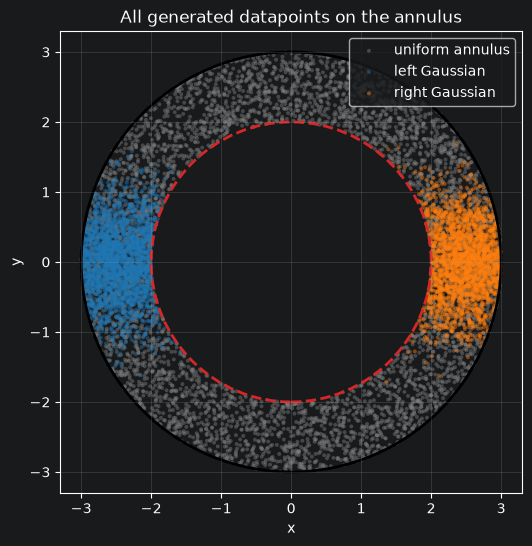

In [3]:
all_generated_points = np.vstack((points, gaussian_ring_points))

source_labels = np.concatenate(
    (
        np.full(points.shape[0], "uniform annulus", dtype=object),
        np.where(gaussian_ring_labels == 0, "left Gaussian", "right Gaussian").astype(object),
    )
)

source_palette = {
    "uniform annulus": "tab:gray",
    "left Gaussian": "tab:blue",
    "right Gaussian": "tab:orange",
}
source_colors = np.array([source_palette[label] for label in source_labels])

print("all_generated_points shape:", all_generated_points.shape)
print("source counts:")
for label in source_palette:
    print(f"  {label}: {np.sum(source_labels == label)}")

fig, ax = plt.subplots(figsize=(7, 6))
for label, color in source_palette.items():
    mask = source_labels == label
    ax.scatter(
        all_generated_points[mask, 0],
        all_generated_points[mask, 1],
        s=8,
        alpha=0.45,
        edgecolors="none",
        color=color,
        label=label,
    )

ax.add_patch(
    plt.Circle((0, 0), inner_radius, fill=False, linestyle="--", color="tab:red", linewidth=2)
)
ax.add_patch(plt.Circle((0, 0), outer_radius, fill=False, color="black", linewidth=2))
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("All generated datapoints on the annulus")
ax.legend(loc="upper right")
ax.grid(alpha=0.25)
plt.show()


### Build a weighted kNN graph

The graph is the discrete approximation of the annulus data manifold. Here `sigma=None` uses the median non-self kNN distance as the Gaussian bandwidth, which is scale-appropriate for the toy coordinates.


In [4]:
from scipy.sparse.csgraph import connected_components
from cellflow.preprocessing._premetric import (
    SpectralNystroem,
    build_knn_graph,
    compute_eigens,
    normalized_laplacian,
    spectral_embedding,
)
import jax.numpy as jnp

knn_k = 30
W, sigma = build_knn_graph(
    all_generated_points,
    k=knn_k,
    sigma=None,
    symmetrize="max",
    remove_self=True,
)

diag = W.diagonal()
print("diagonal min:", diag.min())
print("diagonal max:", diag.max())
print("diagonal mean:", diag.mean())
print("nonzero diagonal count:", np.sum(diag != 0))

n_components, component_labels = connected_components(W, directed=False)
component_sizes = np.bincount(component_labels)
print("number of connected components:", n_components)
print("component sizes:", np.sort(component_sizes)[::-1][:20])

W_no_diag = W.copy()
W_no_diag.setdiag(0)
W_no_diag.eliminate_zeros()

print("non-self weight min:", W_no_diag.data.min())
print("non-self weight median:", np.median(W_no_diag.data))
print("non-self weight max:", W_no_diag.data.max())
print("non-self nnz:", W_no_diag.nnz)
print("sigma:", sigma)
print("weight quantiles:")
print(np.quantile(W_no_diag.data, [0, 0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 1.0]))


C:\Users\marku\PycharmProjects\CellFlow\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


diagonal min: 0.0
diagonal max: 0.0
diagonal mean: 0.0
nonzero diagonal count: 0
number of connected components: 1
component sizes: [10000]
non-self weight min: 7.872941591369201e-05
non-self weight median: 0.574302287449598
non-self weight max: 0.9999818270950381
non-self nnz: 331978
sigma: 0.0657412597747254
weight quantiles:
[7.87294159e-05 6.82812944e-04 4.48915333e-03 2.45126898e-02
 5.74302287e-01 9.49843934e-01 9.89570961e-01 9.99981827e-01]


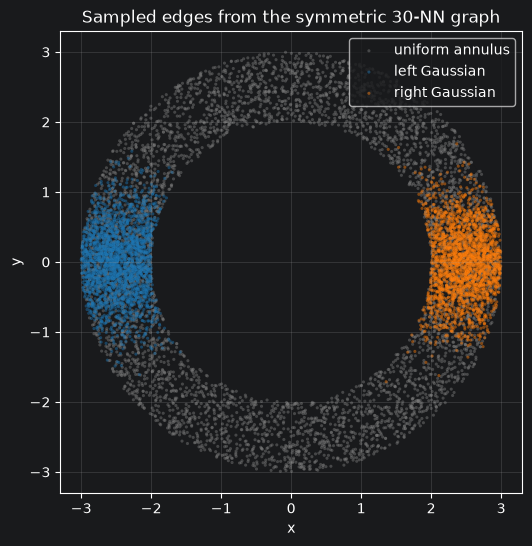

In [5]:
graph_rng = np.random.default_rng(7)
W_edges = W_no_diag.tocoo()
upper_edge_mask = W_edges.row < W_edges.col
edge_rows = W_edges.row[upper_edge_mask]
edge_cols = W_edges.col[upper_edge_mask]
edge_ids = graph_rng.choice(
    len(edge_rows),
    size=min(5_000, len(edge_rows)),
    replace=False,
)

fig, ax = plt.subplots(figsize=(7, 6))
for edge_id in edge_ids:
    i = edge_rows[edge_id]
    j = edge_cols[edge_id]
    ax.plot(
        all_generated_points[[i, j], 0],
        all_generated_points[[i, j], 1],
        color="black",
        alpha=0.015,
        linewidth=0.5,
    )

for label, color in source_palette.items():
    mask = source_labels == label
    ax.scatter(
        all_generated_points[mask, 0],
        all_generated_points[mask, 1],
        s=5,
        alpha=0.45,
        edgecolors="none",
        color=color,
        label=label,
    )

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Sampled edges from the symmetric {knn_k}-NN graph")
ax.legend(loc="upper right")
ax.grid(alpha=0.25)
plt.show()


### Laplacian eigenvectors and spectral pre-metric coordinates

We remove the trivial constant eigenvector and use the next eigenvectors to construct biharmonic spectral coordinates. Squared Euclidean distances in this spectral space give the pre-metric used below.


raw eigenvalues: [5.24142087e-08 4.08864234e-05 4.73483414e-04 5.96719914e-04
 1.65552701e-03 2.08035849e-03 2.55130675e-03 3.27080912e-03
 4.14668088e-03]
kept eigenvalues: [4.08864234e-05 4.73483414e-04 5.96719914e-04 1.65552701e-03
 2.08035849e-03 2.55130675e-03 3.27080912e-03 4.14668088e-03]
Psi shape: (10000, 8)
Psi norm range: (np.float32(721.3909), np.float32(142188.44))


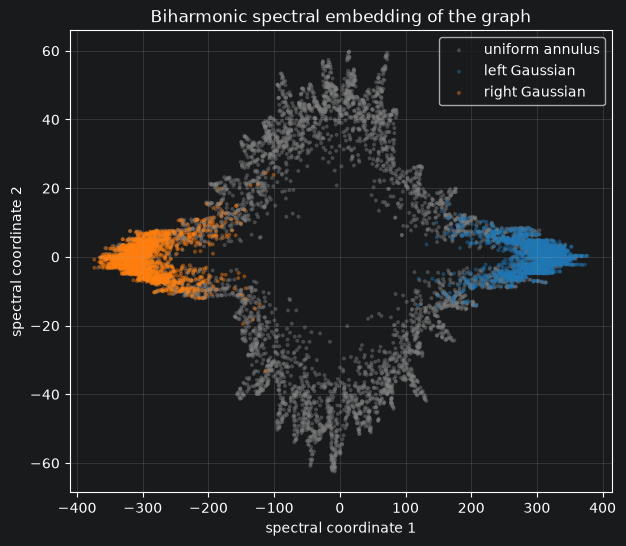

In [6]:
L = normalized_laplacian(W)

n_nontrivial_eigenvectors = 8
np.random.seed(0)
raw_evals, raw_evecs = compute_eigens(L, k=n_nontrivial_eigenvectors + 1)

order = np.argsort(raw_evals)
raw_evals = raw_evals[order]
raw_evecs = raw_evecs[:, order]

evals = raw_evals[1 : n_nontrivial_eigenvectors + 1]
evecs = raw_evecs[:, 1 : n_nontrivial_eigenvectors + 1]

if np.any(evals <= 0):
    print("Warning: non-positive non-trivial eigenvalues were clipped before spectral scaling.")
    evals = np.maximum(evals, 1e-12)

Psi = spectral_embedding(evals, evecs, weight_type="biharmonic").astype(np.float32)
Psi_norm = np.sum(Psi * Psi, axis=1)

print("raw eigenvalues:", raw_evals[: n_nontrivial_eigenvectors + 1])
print("kept eigenvalues:", evals)
print("Psi shape:", Psi.shape)
print("Psi norm range:", (Psi_norm.min(), Psi_norm.max()))

fig, ax = plt.subplots(figsize=(7, 6))
for label, color in source_palette.items():
    mask = source_labels == label
    ax.scatter(
        Psi[mask, 0],
        Psi[mask, 1],
        s=8,
        alpha=0.45,
        edgecolors="none",
        color=color,
        label=label,
    )

ax.set_xlabel("spectral coordinate 1")
ax.set_ylabel("spectral coordinate 2")
ax.set_title("Biharmonic spectral embedding of the graph")
ax.legend(loc="best")
ax.grid(alpha=0.25)
plt.show()


### Precompute the dense squared pre-metric

For 10,000 generated points, a dense float32 matrix takes about 400 MB. The helper below computes it in row blocks so the temporary matrix products stay bounded.


D shape: (10000, 10000)
D dtype: float32
D memory GB: 0.3725290298461914
max diagonal entry: 0.0
sample symmetry error: 0.0
five nearest points to point 0 by pre-metric: [1612 2251  431 4699  934]
their squared pre-metric distances: [1.3017578 1.3398438 2.6445312 3.5498047 3.881836 ]


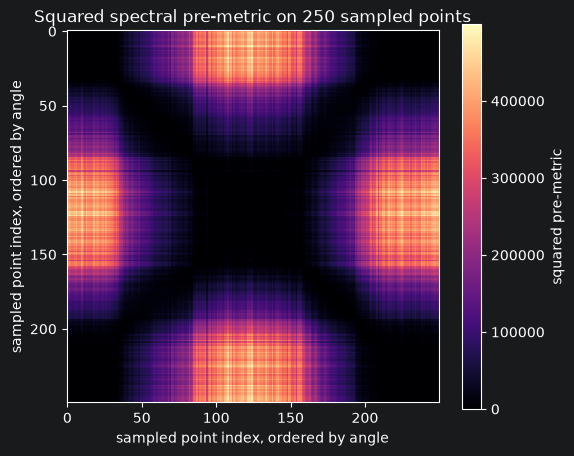

In [7]:
def squared_spectral_distance_matrix(psi, block_size=1_000, dtype=np.float32):
    psi = np.asarray(psi, dtype=dtype)
    sq_norm = np.sum(psi * psi, axis=1, dtype=dtype)
    distances = np.empty((psi.shape[0], psi.shape[0]), dtype=dtype)

    for start in range(0, psi.shape[0], block_size):
        stop = min(start + block_size, psi.shape[0])
        distances[start:stop] = (
            sq_norm[start:stop, None]
            + sq_norm[None, :]
            - 2.0 * (psi[start:stop] @ psi.T)
        )

    np.maximum(distances, 0, out=distances)
    np.fill_diagonal(distances, 0.0)
    return distances

dense_premetric_block_size = 1_000
D = squared_spectral_distance_matrix(Psi, block_size=dense_premetric_block_size)

check_rng = np.random.default_rng(13)
check_ids = check_rng.choice(D.shape[0], size=min(512, D.shape[0]), replace=False)
D_check = D[np.ix_(check_ids, check_ids)]

query_index = 0
nearest_by_premetric = np.argsort(D[query_index])[1:6]

print("D shape:", D.shape)
print("D dtype:", D.dtype)
print("D memory GB:", D.nbytes / 1024**3)
print("max diagonal entry:", np.max(np.diag(D)))
print("sample symmetry error:", np.max(np.abs(D_check - D_check.T)))
print("five nearest points to point 0 by pre-metric:", nearest_by_premetric)
print("their squared pre-metric distances:", D[query_index, nearest_by_premetric])

heatmap_rng = np.random.default_rng(19)
heatmap_ids = heatmap_rng.choice(D.shape[0], size=250, replace=False)
heatmap_angles = np.arctan2(all_generated_points[heatmap_ids, 1], all_generated_points[heatmap_ids, 0])
heatmap_ids = heatmap_ids[np.argsort(heatmap_angles)]

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(D[np.ix_(heatmap_ids, heatmap_ids)], cmap="magma", interpolation="nearest")
ax.set_title("Squared spectral pre-metric on 250 sampled points")
ax.set_xlabel("sampled point index, ordered by angle")
ax.set_ylabel("sampled point index, ordered by angle")
fig.colorbar(image, ax=ax, label="squared pre-metric")
plt.show()


### Stream new points into the pre-metric space

The precomputed graph eigenvectors also give a Nystroem-style interpolator for points that were not in the graph fit.


new point: [0.  2.5]
nearest graph points by streamed pre-metric: [1276 1628 1444 3101 4477 4867 4377 3899  254 4437]
squared pre-metric distances: [287895.34 288002.2  288721.03 289389.22 289684.5  289729.28 289795.7
 290039.94 290287.34 290529.7 ]


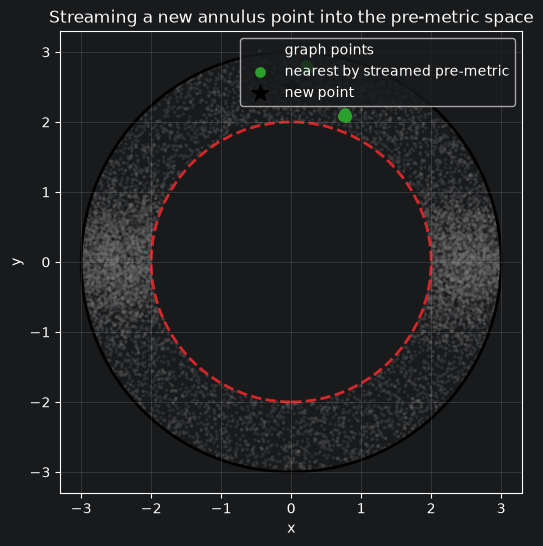

In [8]:
key_array = jnp.asarray(all_generated_points)
nystroem = SpectralNystroem(
    all_generated_points,
    evecs,
    evals,
    sigma=sigma,
    psi=Psi,
    x_to_id=key_array,
    k=knn_k,
)

new_point = np.array([0.0, 2.5], dtype=np.float32)
new_emb = np.asarray(nystroem.embed_point(jnp.asarray(new_point))).astype(np.float32)
new_point_distances = np.sum((Psi - new_emb[None, :]) ** 2, axis=1)
nearest_to_new_point = np.argsort(new_point_distances)[:10]

print("new point:", new_point)
print("nearest graph points by streamed pre-metric:", nearest_to_new_point)
print("squared pre-metric distances:", new_point_distances[nearest_to_new_point])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    all_generated_points[:, 0],
    all_generated_points[:, 1],
    s=6,
    alpha=0.18,
    edgecolors="none",
    color="tab:gray",
    label="graph points",
)
ax.scatter(
    all_generated_points[nearest_to_new_point, 0],
    all_generated_points[nearest_to_new_point, 1],
    s=45,
    color="tab:green",
    label="nearest by streamed pre-metric",
)
ax.scatter(
    new_point[0],
    new_point[1],
    s=160,
    marker="*",
    color="black",
    label="new point",
)
ax.add_patch(
    plt.Circle((0, 0), inner_radius, fill=False, linestyle="--", color="tab:red", linewidth=2)
)
ax.add_patch(plt.Circle((0, 0), outer_radius, fill=False, color="black", linewidth=2))
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Streaming a new annulus point into the pre-metric space")
ax.legend(loc="upper right")
ax.grid(alpha=0.25)
plt.show()


### Inspect the RFM interpolation field `u_t`

The `RFMInterpolation` class defines the target-conditioned field used inside `OTRFlowMatching`. The current Nystroem implementation looks up the target spectral embedding by exact coordinates, so `x1` is selected from the graph-backed generated datapoints.


target x1: [2.489612e+00 5.334939e-04]
u_t speed range: (np.float32(0.17036933), np.float32(20.828579))


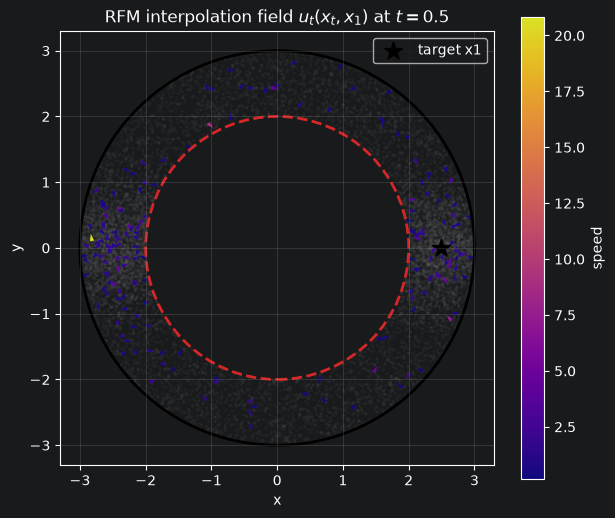

In [9]:
from cellflow.ode_solver._rfm_interpolation import RFMInterpolation

rfm_interpolator = RFMInterpolation(nystroem)

ut_rng = np.random.default_rng(33)
rfm_target_local_idx = int(np.argmin(np.linalg.norm(right_gaussian_points - mean_right, axis=1)))
x1 = right_gaussian_points[rfm_target_local_idx].astype(np.float32)

n_ut_vectors = 180
xt_sample_ids = ut_rng.choice(all_generated_points.shape[0], n_ut_vectors, replace=False)
xt_samples = all_generated_points[xt_sample_ids].astype(np.float32)
x1_batch = np.repeat(x1[None, :], xt_samples.shape[0], axis=0)

ut_time = 0.5
u_samples = np.asarray(
    rfm_interpolator.u_t(
        jnp.asarray(xt_samples),
        jnp.asarray(x1_batch),
        ut_time,
    )
)
u_speed = np.linalg.norm(u_samples, axis=1)
u_directions = u_samples / np.maximum(u_speed[:, None], 1e-8)

print("target x1:", x1)
print("u_t speed range:", (u_speed.min(), u_speed.max()))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    all_generated_points[:, 0],
    all_generated_points[:, 1],
    s=5,
    alpha=0.08,
    edgecolors="none",
    color="tab:gray",
)
quiver = ax.quiver(
    xt_samples[:, 0],
    xt_samples[:, 1],
    u_directions[:, 0],
    u_directions[:, 1],
    u_speed,
    cmap="plasma",
    angles="xy",
    scale_units="xy",
    scale=9,
    width=0.004,
    alpha=0.9,
)
ax.scatter(x1[0], x1[1], s=180, marker="*", color="black", label="target x1")
ax.add_patch(
    plt.Circle((0, 0), inner_radius, fill=False, linestyle="--", color="tab:red", linewidth=2)
)
ax.add_patch(plt.Circle((0, 0), outer_radius, fill=False, color="black", linewidth=2))
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"RFM interpolation field $u_t(x_t, x_1)$ at $t = 0.5$")
ax.legend(loc="upper right")
ax.grid(alpha=0.25)
fig.colorbar(quiver, ax=ax, label="speed")
plt.show()


start x0: [-2.6369607 -0.582489 ]
target x1: [2.489612e+00 5.334939e-04]
last interpolated point: [-2.8986526 -0.7104342]
distance from last interpolated point to x1: 5.4349675


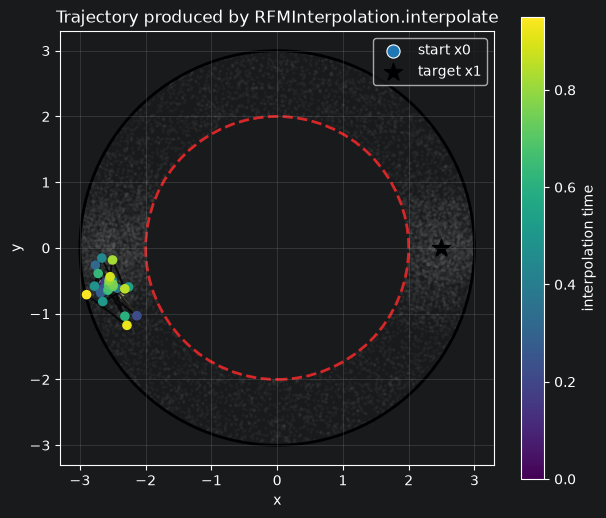

In [10]:
rfm_start_global_idx = 1382
x0 = all_generated_points[rfm_start_global_idx].astype(np.float32)

trajectory_times = np.linspace(0.0, 0.95, 31, dtype=np.float32)
trajectory_steps_per_eval = 250
rfm_trajectory = np.vstack(
    [
        np.asarray(
            rfm_interpolator.interpolate(
                jnp.asarray(x0[None, :]),
                jnp.asarray(x1[None, :]),
                float(t),
                trajectory_steps_per_eval,
            )
        )[0]
        for t in trajectory_times
    ]
)

trajectory_vectors = np.asarray(
    rfm_interpolator.u_t(
        jnp.asarray(rfm_trajectory),
        jnp.asarray(np.repeat(x1[None, :], rfm_trajectory.shape[0], axis=0)),
        0.5,
    )
)
trajectory_speed = np.linalg.norm(trajectory_vectors, axis=1)

print("start x0:", x0)
print("target x1:", x1)
print("last interpolated point:", rfm_trajectory[-1])
print("distance from last interpolated point to x1:", np.linalg.norm(rfm_trajectory[-1] - x1))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    all_generated_points[:, 0],
    all_generated_points[:, 1],
    s=5,
    alpha=0.08,
    edgecolors="none",
    color="tab:gray",
)
path = ax.scatter(
    rfm_trajectory[:, 0],
    rfm_trajectory[:, 1],
    c=trajectory_times,
    cmap="viridis",
    s=35,
    zorder=3,
)
ax.plot(rfm_trajectory[:, 0], rfm_trajectory[:, 1], color="black", linewidth=1.5, alpha=0.75)
ax.scatter(x0[0], x0[1], s=90, color="tab:blue", edgecolors="white", linewidths=0.8, label="start x0")
ax.scatter(x1[0], x1[1], s=180, marker="*", color="black", label="target x1")
ax.quiver(
    rfm_trajectory[:, 0],
    rfm_trajectory[:, 1],
    trajectory_vectors[:, 0],
    trajectory_vectors[:, 1],
    trajectory_speed,
    cmap="magma",
    angles="xy",
    scale_units="xy",
    scale=35,
    width=0.004,
    alpha=0.55,
)
ax.add_patch(
    plt.Circle((0, 0), inner_radius, fill=False, linestyle="--", color="tab:red", linewidth=2)
)
ax.add_patch(plt.Circle((0, 0), outer_radius, fill=False, color="black", linewidth=2))
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Trajectory produced by RFMInterpolation.interpolate")
ax.legend(loc="upper right")
ax.grid(alpha=0.25)
fig.colorbar(path, ax=ax, label="interpolation time")
plt.show()


## Toy Riemannian Flow Matching on the annulus

In this toy example, the left Gaussian is the control distribution and the right Gaussian is the perturbed distribution. The CellFlow model is trained with the `otrfm` solver, using the spectral Nystroem pre-metric fit above to define Riemannian interpolation on the annulus manifold.


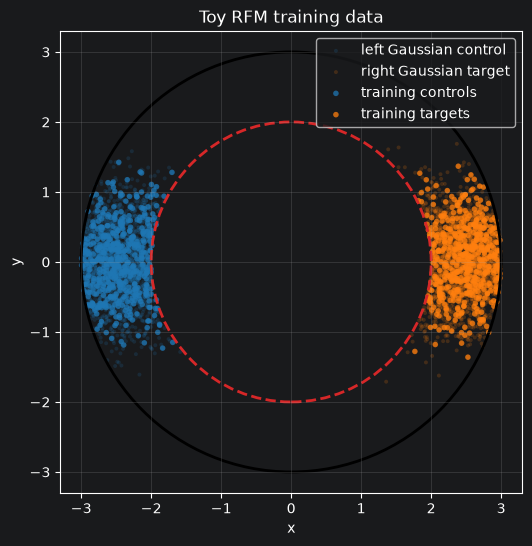

In [11]:
import anndata as ad
import functools
import jax
import optax
import pandas as pd
import flax.linen as nn

from cellflow.model import CellFlow
from cellflow.utils import match_linear

toy_rng = np.random.default_rng(2026)
toy_n_train_per_group = 512

toy_left_idx = toy_rng.choice(left_gaussian_points.shape[0], toy_n_train_per_group, replace=False)
toy_right_idx = toy_rng.choice(right_gaussian_points.shape[0], toy_n_train_per_group, replace=False)

toy_train_points = np.vstack(
    (
        left_gaussian_points[toy_left_idx],
        right_gaussian_points[toy_right_idx],
    )
).astype(np.float32)

toy_obs = pd.DataFrame(
    {
        "is_control": np.concatenate(
            (
                np.ones(toy_n_train_per_group, dtype=bool),
                np.zeros(toy_n_train_per_group, dtype=bool),
            )
        ),
        "toy_perturbation": pd.Categorical(
            ["control"] * toy_n_train_per_group + ["right_shift"] * toy_n_train_per_group
        ),
    },
    index=[f"toy_cell_{i}" for i in range(2 * toy_n_train_per_group)],
)

toy_adata = ad.AnnData(X=toy_train_points, obs=toy_obs)
toy_adata.uns["toy_perturbation_embeddings"] = {
    "control": np.array([0.0], dtype=np.float32),
    "right_shift": np.array([1.0], dtype=np.float32),
}

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    left_gaussian_points[:, 0],
    left_gaussian_points[:, 1],
    s=8,
    alpha=0.18,
    edgecolors="none",
    color="tab:blue",
    label="left Gaussian control",
)
ax.scatter(
    right_gaussian_points[:, 0],
    right_gaussian_points[:, 1],
    s=8,
    alpha=0.18,
    edgecolors="none",
    color="tab:orange",
    label="right Gaussian target",
)
ax.scatter(
    toy_train_points[:toy_n_train_per_group, 0],
    toy_train_points[:toy_n_train_per_group, 1],
    s=16,
    alpha=0.75,
    edgecolors="none",
    color="tab:blue",
    label="training controls",
)
ax.scatter(
    toy_train_points[toy_n_train_per_group:, 0],
    toy_train_points[toy_n_train_per_group:, 1],
    s=16,
    alpha=0.75,
    edgecolors="none",
    color="tab:orange",
    label="training targets",
)
ax.add_patch(
    plt.Circle((0, 0), inner_radius, fill=False, linestyle="--", color="tab:red", linewidth=2)
)
ax.add_patch(plt.Circle((0, 0), outer_radius, fill=False, color="black", linewidth=2))
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Toy RFM training data")
ax.legend(loc="upper right")
ax.grid(alpha=0.25)
plt.show()


In [12]:
toy_cf = CellFlow(toy_adata, solver="otrfm")
toy_cf.prepare_data(
    sample_rep="X",
    control_key="is_control",
    perturbation_covariates={"toy_perturbation": ("toy_perturbation",)},
    perturbation_covariate_reps={"toy_perturbation": "toy_perturbation_embeddings"},
    max_combination_length=1,
    null_value=0.0,
)

toy_train_data = toy_cf.train_data
print("cell data shape:", toy_train_data.cell_data.shape)
print("condition keys:", list(toy_train_data.condition_data))
print("control-to-perturbation mapping:", toy_train_data.control_to_perturbation)
print("perturbation labels:", toy_train_data.perturbation_idx_to_covariates)


[########################################] | 100% Completed | 102.54 ms
[########################################] | 100% Completed | 102.54 ms
[########################################] | 100% Completed | 102.00 ms
cell data shape: (1024, 2)
condition keys: ['toy_perturbation']
control-to-perturbation mapping: {0: array([0], dtype=int32)}
perturbation labels: {0: ['right_shift']}


### Train a compact OTRFM model

This is intentionally much smaller than the PBMC model: the state is only 2D, there is one toy condition, and the goal is to visualize the learned field rather than maximize predictive accuracy.


In [13]:
toy_layers_before_pool = {
    "toy_perturbation": {"layer_type": "mlp", "dims": [16], "dropout_rate": 0.0},
}
toy_layers_after_pool = {
    "layer_type": "mlp",
    "dims": [16],
    "dropout_rate": 0.0,
}

toy_match_fn = functools.partial(match_linear, epsilon=0.5, tau_a=1.0, tau_b=1.0)

toy_cf.prepare_model(
    condition_mode="deterministic",
    regularization=0.0,
    pooling="mean",
    pooling_kwargs={},
    layers_before_pool=toy_layers_before_pool,
    layers_after_pool=toy_layers_after_pool,
    condition_embedding_dim=16,
    cond_output_dropout=0.0,
    condition_encoder_kwargs={},
    pool_sample_covariates=True,
    time_freqs=16,
    time_encoder_dims=[32, 32],
    time_encoder_dropout=0.0,
    hidden_dims=[32, 32],
    hidden_dropout=0.0,
    conditioning="concatenation",
    decoder_dims=[32, 32],
    vf_act_fn=nn.silu,
    vf_kwargs=None,
    probability_path={"constant_noise": 0.0},
    match_fn=toy_match_fn,
    optimizer=optax.adam(1e-3),
    solver_kwargs={},
    layer_norm_before_concatenation=False,
    linear_projection_before_concatenation=False,
    nystroem=nystroem,
    seed=0,
)

toy_num_iterations = 300
toy_batch_size = 32
toy_cf.train(
    num_iterations=toy_num_iterations,
    batch_size=toy_batch_size,
    callbacks=[],
    valid_freq=10_000,
)


100%|██████████| 300/300 [00:55<00:00,  5.42it/s]


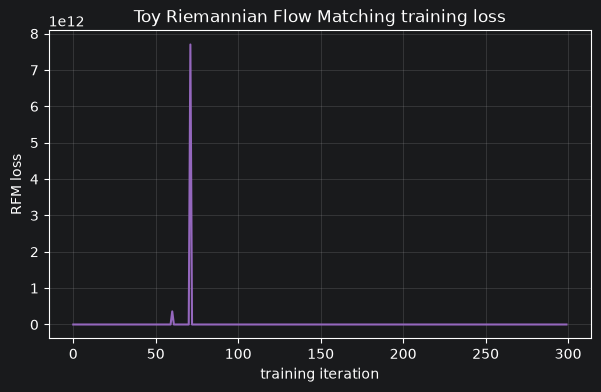

In [14]:
toy_loss = np.asarray(toy_cf.trainer.training_logs["loss"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(toy_loss, color="tab:purple")
ax.set_xlabel("training iteration")
ax.set_ylabel("RFM loss")
ax.set_title("Toy Riemannian Flow Matching training loss")
ax.grid(alpha=0.25)
plt.show()


### Plot learned flow curves and vector field

We evaluate the trained vector field under the `right_shift` condition, integrate trajectories with an explicit Euler solver, and plot a quiver field at the midpoint time `t=0.5`.


In [15]:
def get_toy_condition(cf, label="right_shift"):
    condition_idx = next(
        idx
        for idx, covariates in cf.train_data.perturbation_idx_to_covariates.items()
        if covariates[0] == label
    )
    return {
        key: jnp.asarray(value[[condition_idx]])
        for key, value in cf.train_data.condition_data.items()
    }

def evaluate_learned_vector_field(cf, x, condition, t=0.5, chunk_size=512):
    x = np.asarray(x, dtype=np.float32)
    vectors = []
    encoder_noise = jnp.zeros((1, cf.solver.vf.condition_embedding_dim))

    for start in range(0, x.shape[0], chunk_size):
        stop = min(start + chunk_size, x.shape[0])
        x_chunk = jnp.asarray(x[start:stop])
        t_chunk = jnp.full((x_chunk.shape[0], 1), t)
        v_chunk = cf.solver.vf_state_inference.apply_fn(
            {"params": cf.solver.vf_state_inference.params},
            t_chunk,
            x_chunk,
            condition,
            encoder_noise,
            train=False,
        )[0]
        vectors.append(np.asarray(v_chunk))

    return np.vstack(vectors)

def integrate_learned_flow(cf, x0, condition, n_steps=80):
    x = np.asarray(x0, dtype=np.float32)
    trajectory = np.empty((n_steps + 1, x.shape[0], x.shape[1]), dtype=np.float32)
    trajectory[0] = x
    dt = 1.0 / n_steps

    for step in range(n_steps):
        t = step * dt
        v = evaluate_learned_vector_field(cf, x, condition, t=t)
        x = x + dt * v
        trajectory[step + 1] = x

    return trajectory


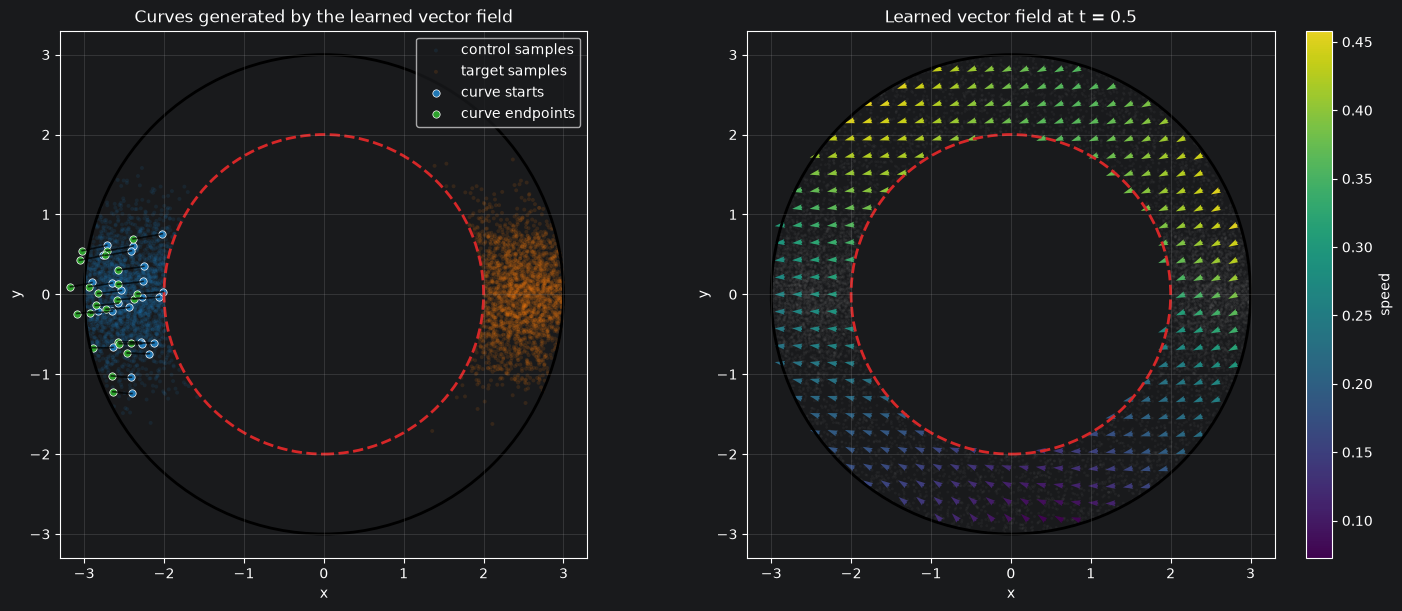

In [16]:
toy_condition = get_toy_condition(toy_cf, label="right_shift")

n_flow_curves = 24
curve_start_idx = toy_rng.choice(left_gaussian_points.shape[0], n_flow_curves, replace=False)
curve_start_points = left_gaussian_points[curve_start_idx].astype(np.float32)
toy_flow_curves = integrate_learned_flow(toy_cf, curve_start_points, toy_condition, n_steps=80)

grid_axis = np.linspace(-3.05, 3.05, 29)
grid_x, grid_y = np.meshgrid(grid_axis, grid_axis)
grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel())).astype(np.float32)
grid_radius = np.linalg.norm(grid_points, axis=1)
annulus_grid_mask = (grid_radius >= inner_radius) & (grid_radius <= outer_radius)
annulus_grid_points = grid_points[annulus_grid_mask]

vector_grid = evaluate_learned_vector_field(toy_cf, annulus_grid_points, toy_condition, t=0.5)
vector_speed = np.linalg.norm(vector_grid, axis=1)
vector_grid_unit = vector_grid / np.maximum(vector_speed[:, None], 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

ax = axes[0]
ax.scatter(
    left_gaussian_points[:, 0],
    left_gaussian_points[:, 1],
    s=8,
    alpha=0.12,
    edgecolors="none",
    color="tab:blue",
    label="control samples",
)
ax.scatter(
    right_gaussian_points[:, 0],
    right_gaussian_points[:, 1],
    s=8,
    alpha=0.12,
    edgecolors="none",
    color="tab:orange",
    label="target samples",
)
for curve_idx in range(n_flow_curves):
    ax.plot(
        toy_flow_curves[:, curve_idx, 0],
        toy_flow_curves[:, curve_idx, 1],
        color="black",
        alpha=0.7,
        linewidth=1.2,
    )
ax.scatter(
    toy_flow_curves[0, :, 0],
    toy_flow_curves[0, :, 1],
    s=28,
    color="tab:blue",
    edgecolors="white",
    linewidths=0.5,
    label="curve starts",
)
ax.scatter(
    toy_flow_curves[-1, :, 0],
    toy_flow_curves[-1, :, 1],
    s=28,
    color="tab:green",
    edgecolors="white",
    linewidths=0.5,
    label="curve endpoints",
)
ax.add_patch(
    plt.Circle((0, 0), inner_radius, fill=False, linestyle="--", color="tab:red", linewidth=2)
)
ax.add_patch(plt.Circle((0, 0), outer_radius, fill=False, color="black", linewidth=2))
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Curves generated by the learned vector field")
ax.legend(loc="upper right")
ax.grid(alpha=0.25)

ax = axes[1]
ax.scatter(
    all_generated_points[:, 0],
    all_generated_points[:, 1],
    s=4,
    alpha=0.08,
    edgecolors="none",
    color="tab:gray",
)
quiver = ax.quiver(
    annulus_grid_points[:, 0],
    annulus_grid_points[:, 1],
    vector_grid_unit[:, 0],
    vector_grid_unit[:, 1],
    vector_speed,
    cmap="viridis",
    angles="xy",
    scale_units="xy",
    scale=8,
    width=0.004,
    alpha=0.9,
)
ax.add_patch(
    plt.Circle((0, 0), inner_radius, fill=False, linestyle="--", color="tab:red", linewidth=2)
)
ax.add_patch(plt.Circle((0, 0), outer_radius, fill=False, color="black", linewidth=2))
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Learned vector field at t = 0.5")
ax.grid(alpha=0.25)
fig.colorbar(quiver, ax=ax, label="speed")

plt.show()
